In [3]:
# setup:
# 1000 items, 1000 + 1000 queries
recall_k = 5
n_runs = 10
n_items_per_run = 1000
test_item_cnt = 100
item_cnt_range = list(range(5, 101, 5))
assert test_item_cnt in item_cnt_range

In [31]:
from collections import defaultdict
from itertools import combinations

from matplotlib import pyplot as plt
import numpy as np
import os
from sklearn.metrics import top_k_accuracy_score
from sklearn.cluster import KMeans
from scipy.stats import mannwhitneyu, ttest_rel

In [5]:
with open("collections_10000_items/test.npy", "rb") as fin:
    all_test = np.load(fin)
with open("collections_10000_items/train.npy", "rb") as fin:
    all_train = np.load(fin)
assert all_train.shape[0] == n_runs * n_items_per_run
assert all_test.shape[0] == n_runs * n_items_per_run


In [6]:
def eval_items(items, train, test):
    item_embeds = train.dot(np.linalg.pinv(train[items]))
    approx_test_rel = item_embeds.dot(test[items])
    approx_train_rel = item_embeds.dot(train[items])
    best_items = np.argsort(test, axis=0)[-1]
    recall = top_k_accuracy_score(best_items, approx_test_rel.T, k=recall_k, labels=np.arange(train.shape[0]))
    test_mse = np.mean((test - approx_test_rel) ** 2)
    train_mse = np.mean((train - approx_train_rel) ** 2)
    return recall, test_mse, train_mse

def get_rnd_items(n_items, train):
    return np.random.choice(train.shape[0], n_items, replace=False)

def get_kmeans_items(n_items, train):
    kmeans = KMeans(n_clusters=n_items, n_init="auto").fit(train)
    items = []
    for center in kmeans.cluster_centers_:
        distances = ((train - center) ** 2).sum(axis=1)
        assert distances.shape == (train.shape[0],)
        for item_id in np.argsort(distances):
            if item_id not in items:
                items.append(item_id)
                break
    return np.array(items, dtype=np.int64)

greedy_items = []
def get_greedy(n_items, train):
    if len(greedy_items) >= n_items:
        return np.array(greedy_items[:n_items], dtype=np.int64)
    
    gram = train.dot(train.T)
    gram /= gram.mean()
    items = []
    remaining_items = np.ones(train.shape[0], dtype="bool")
    for t in range(n_items):
        scores = (gram ** 2).sum(axis=1)
        assert np.allclose(scores[~remaining_items], np.zeros_like(scores[~remaining_items])), (
            t, scores[~remaining_items]
        )
        scores[remaining_items] /= gram[remaining_items, remaining_items]
        if max(scores) < 1e-9:
            break
        new_item = scores.argmax()
        assert remaining_items[new_item]
        coefs = gram[new_item] / np.sqrt(gram[new_item, new_item])
        diff = coefs.reshape(-1, 1).dot(coefs.reshape(1, -1))
        gram -= diff
        assert np.allclose(gram[new_item], np.zeros_like(gram[new_item]), atol=1e-6), (
            t, gram[new_item].std()
        )
        items.append(new_item)
        remaining_items[new_item] = False
    assert len(items) == n_items
    greedy_items.clear()
    greedy_items.extend(items)
    return np.array(items, dtype=np.int64)


In [8]:
item_order = np.arange(all_train.shape[0])
np.random.shuffle(item_order)
methods = {
    "random": get_rnd_items,
    "kmeans": get_kmeans_items,
    "greedy": get_greedy
}
stats = {method: defaultdict(list) for method in methods}

for r in range(n_runs):
    curr_items = item_order[r * n_items_per_run: (r + 1) * n_items_per_run]
    train = np.ascontiguousarray(all_train[curr_items])
    test = np.ascontiguousarray(all_test[curr_items])
    greedy_items.clear()
    get_greedy(max(item_cnt_range), train)
    for method, selector in methods.items():
        recalls, test_mses, train_mses = [], [], []
        for n_items in item_cnt_range:
            items = selector(n_items, train)
            recall, test_mse, train_mse = eval_items(items, train, test)
            recalls.append(recall)
            test_mses.append(test_mse)
            train_mses.append(train_mse)
        stats[method]["recall"].append(recalls)
        stats[method]["test_mse"].append(test_mses)
        stats[method]["train_mse"].append(train_mses)


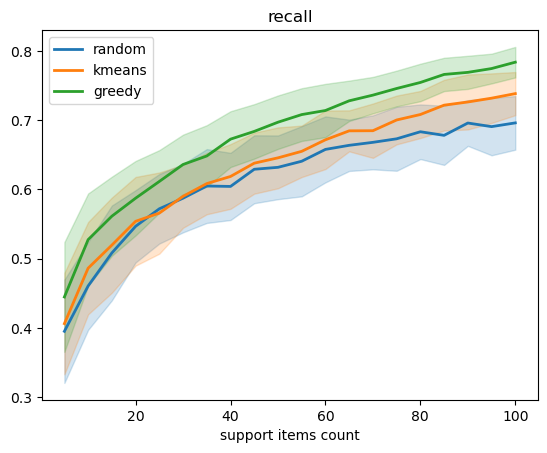

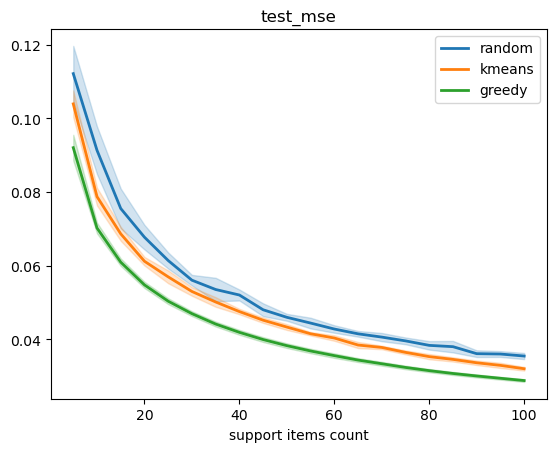

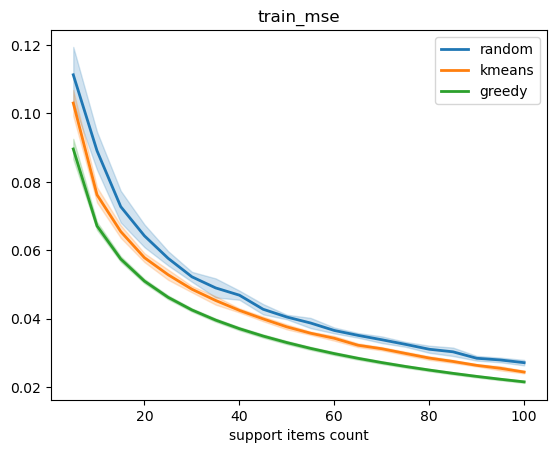

In [27]:
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

for metric in ["recall", "test_mse", "train_mse"]:
    plt.title(metric)
    plt.xlabel("support items count")
    for method, color in zip(methods, colors):
        avg_values = np.array(stats[method][metric]).mean(axis=0)
        stds = np.array(stats[method][metric]).std(axis=0, ddof=1)
        plt.plot(
            item_cnt_range, avg_values, label=method, color=color,
            linewidth=2
        )
        plt.fill_between(item_cnt_range, avg_values - stds, avg_values + stds, color=color, alpha=0.2)
#         for run_values in stats[method][metric]:
#             plt.plot(item_cnt_range, run_values, color=color, linewidth=0.3)
    plt.legend()
    plt.show()


In [29]:
index = item_cnt_range.index(test_item_cnt)
for m in methods:
    recalls = np.array(stats[m]['recall'])[:, index]
    std = recalls.std(ddof=1) / np.sqrt(n_runs)
    print(f"{m:<10} {recalls.mean():<7.3} +- {std:.3f}")

random     0.696   +- 0.012
kmeans     0.738   +- 0.010
greedy     0.784   +- 0.007


In [40]:
for m1, m2 in combinations(methods, 2):
    m1_recalls = np.array(stats[m1]['recall'])[:, index]
    m2_recalls = np.array(stats[m2]['recall'])[:, index]
    ttest_pval = ttest_rel(m1_recalls, m2_recalls).pvalue
    mw_pval = mannwhitneyu(m1_recalls, m2_recalls).pvalue
    print(f"{m1} vs {m2}".ljust(20), f"ttest: {ttest_pval:<10.5f} mann-whitney: {mw_pval:<10.5f}")

random vs kmeans     ttest: 0.00012    mann-whitney: 0.01902   
random vs greedy     ttest: 0.00000    mann-whitney: 0.00024   
kmeans vs greedy     ttest: 0.00005    mann-whitney: 0.00406   
